<a href="https://colab.research.google.com/github/objectrom/Flight-LTO-Emission/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data...
  Shape: 1,532,364 rows x 84 columns
  Feature engineering complete.

Aggregating to airport level...
  Airport feature matrix: (40, 25)
        avg_CO2  avg_NOx  avg_taxi_out  avg_pressure
ORIGIN                                              
ANC       22.83     6.34         16.03       1005.01
ATL       27.82     6.36         18.38        983.44
AVL       17.38     2.77         18.41        943.50
BGR       16.36     2.86         20.39       1008.58
BIH       15.56     2.21         16.38        876.95
BOS       23.37     5.26         21.72       1015.20
BRW       17.92     5.82         10.68       1013.42
BUR       22.85     4.77         19.45        989.28
CLT       25.78     5.88         21.85        992.81
CMI       14.88     2.29         13.59        990.37
COU       15.66     2.32         16.96        985.65
DCA       22.44     4.65         22.11       1017.18
DEN       28.64     6.07         19.52        837.47
DFW       26.99     6.34         19.33        995.40

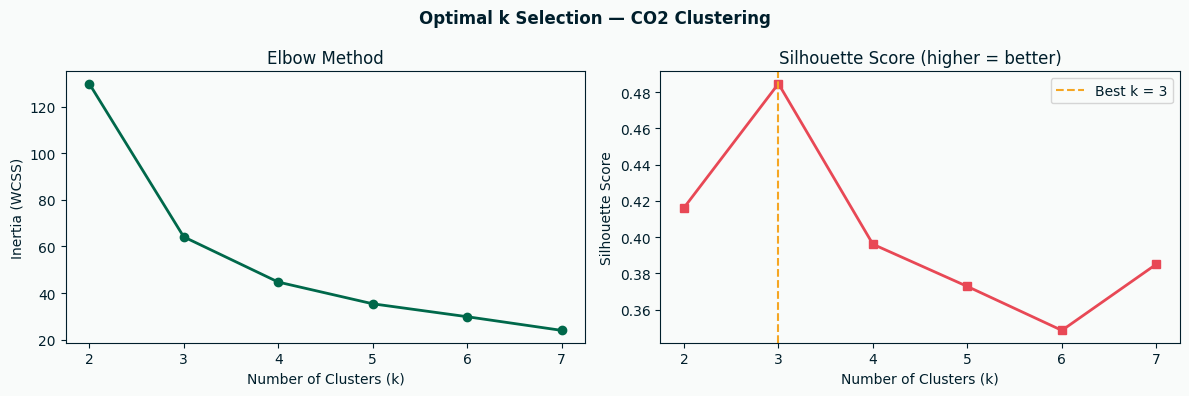

  Suggested k = 3  (silhouette = 0.485)

[CO2] PCA explained variance: [0.322 0.25 ]
[CO2] Silhouette score (k=3): 0.485


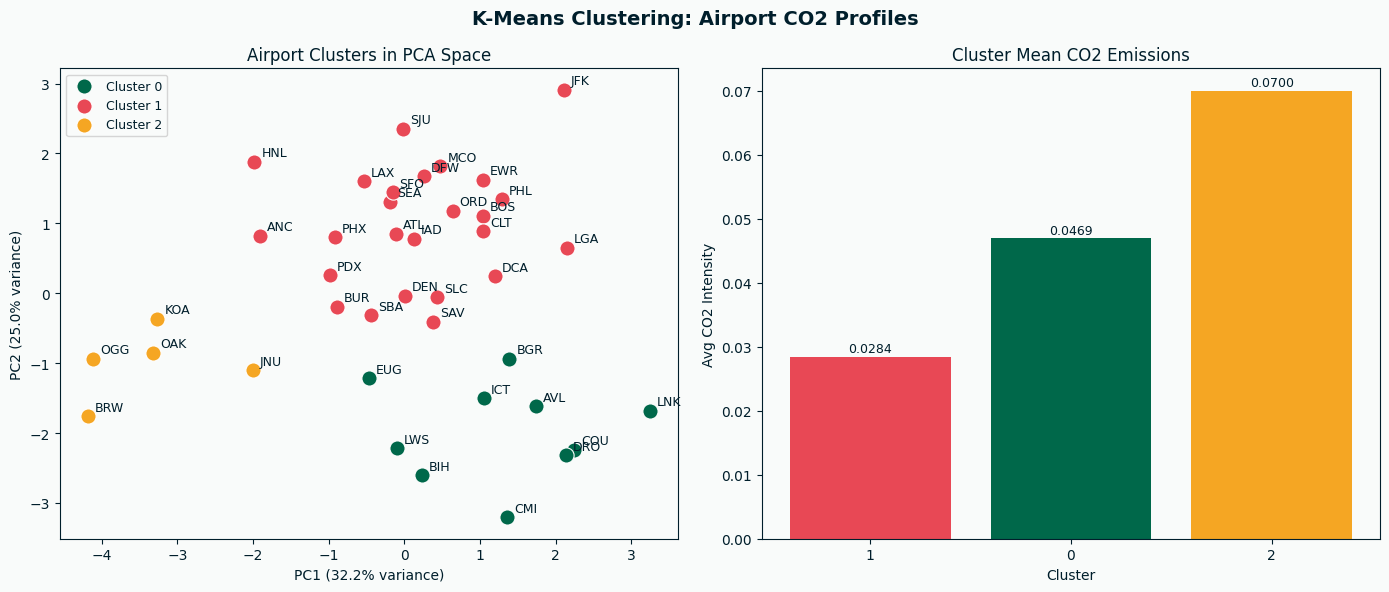

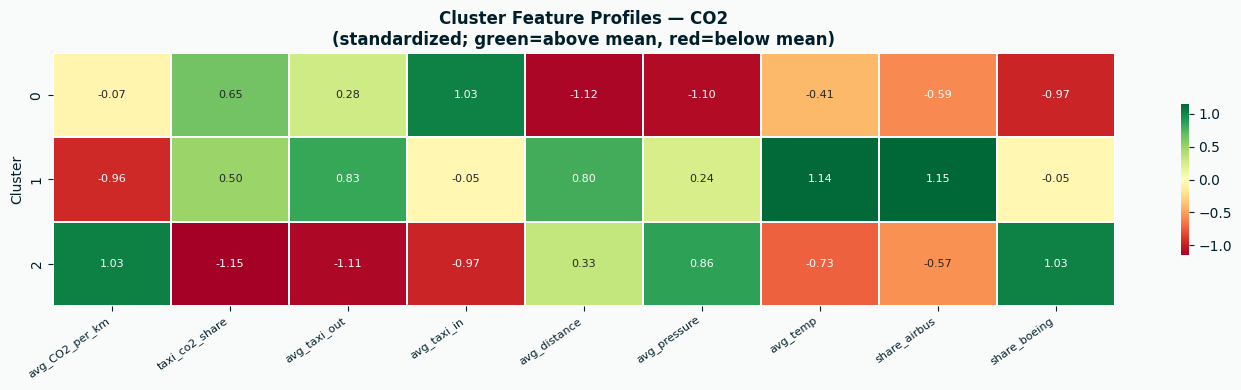


NOx CLUSTERING


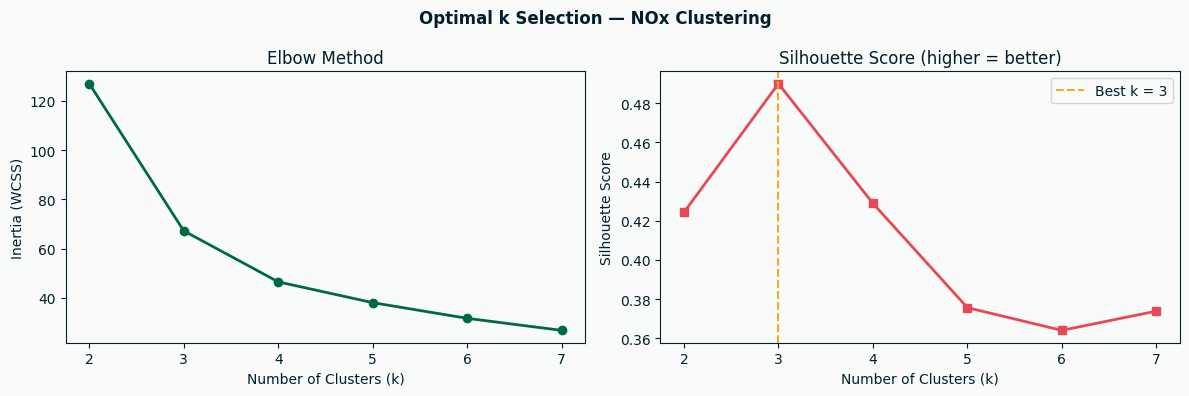

  Suggested k = 3  (silhouette = 0.490)

[NOx] PCA explained variance: [0.346 0.234]
[NOx] Silhouette score (k=3): 0.490


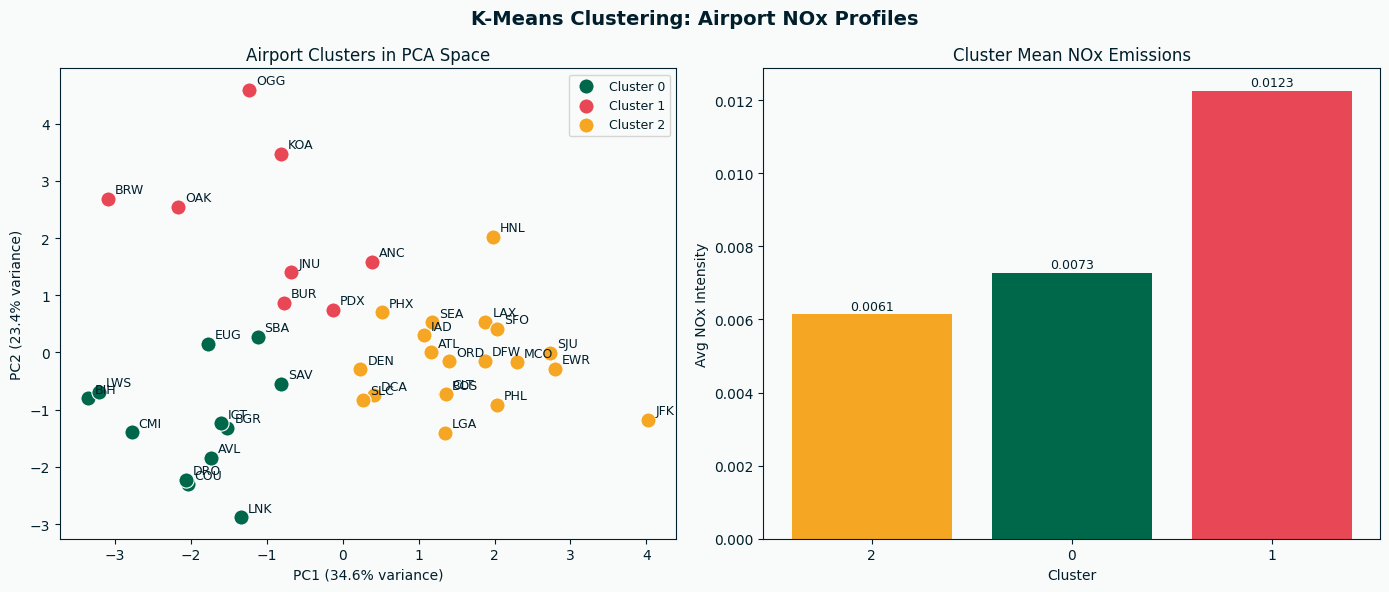

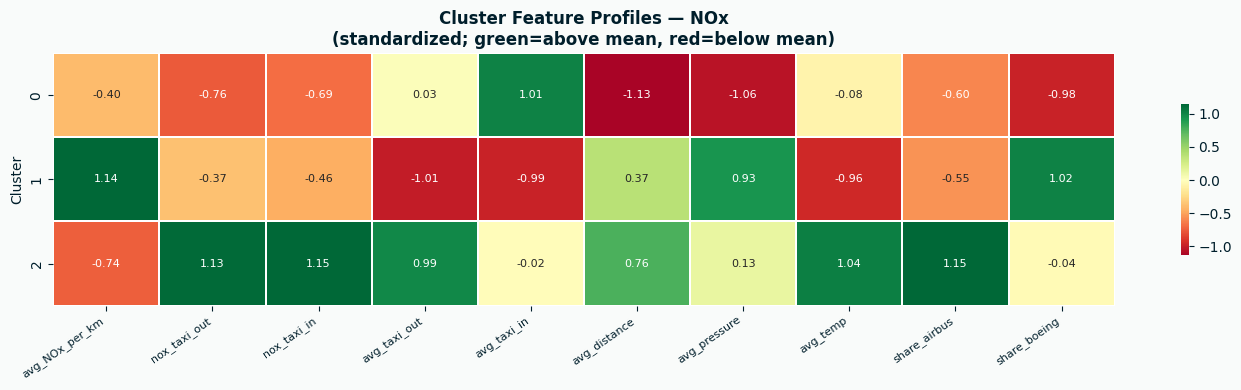


CO2 vs. NOx CLUSTER COMPARISON
       CO2_Cluster NOx_Cluster
ORIGIN                        
ANC              1           1
ATL              1           2
AVL              0           0
BGR              0           0
BIH              0           0
BOS              1           2
BRW              2           1
BUR              1           1
CLT              1           2
CMI              0           0
COU              0           0
DCA              1           2
DEN              1           2
DFW              1           2
DRO              0           0
EUG              0           0
EWR              1           2
HNL              1           2
IAD              1           2
ICT              0           0
JFK              1           2
JNU              2           1
KOA              2           1
LAX              1           2
LGA              1           2
LNK              0           0
LWS              0           0
MCO              1           2
OAK              2           1
OGG    

In [ ]:
"""
Clustering: Airport LTO Emissions Profiles
CIVENG 160D Final Project

Pipeline: Feature Aggregation -> StandardScaler -> PCA -> K-Means
Separate analysis for CO2 and NOx targets.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# ─── Style ────────────────────────────────────────────────────────────────────
PALETTE = {
    "primary": "#00684A", "secondary": "#001E2B", "accent": "#00A35C",
    "warning": "#F5A623", "danger": "#E84855", "muted": "#C1C7C6", "bg": "#F9FBFA",
}
CLUSTER_COLORS = ["#00684A", "#E84855", "#F5A623", "#4A90D9", "#9B59B6", "#1ABC9C", "#FF6B6B"]

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.edgecolor":   PALETTE["secondary"], "axes.labelcolor": PALETTE["secondary"],
    "xtick.color":      PALETTE["secondary"], "ytick.color":     PALETTE["secondary"],
    "text.color":       PALETTE["secondary"], "grid.color":      "#E3E8E6",
    "font.family":      "DejaVu Sans",
})

OUTPUT_DIR = "./"   # change to your preferred output path


# ─── 1. Load & Feature Engineering ───────────────────────────────────────────
print("Loading data...")
df = pd.read_parquet("/content/40_2025_final.parquet")   # adjust path as needed
print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Total LTO CO2 per flight
CO2_COLS = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
df["Total_CO2"] = df[CO2_COLS].sum(axis=1)

# Total LTO NOx per flight: EI (g/kg) x Fuel Flow (kg/s) x Phase Duration (s)
# Airborne phases use ICAO standard LTO times; taxi phases use actual logged times
PHASE_TIMES = {"T/O": 0.7 * 60, "C/O": 2.2 * 60, "App": 4.0 * 60}

df["NOx_TakeOff"]  = (df["NOx EI T/O (g/kg)"]  * df["Fuel Flow T/O (kg/sec)"]  * PHASE_TIMES["T/O"])  / 1000
df["NOx_ClimbOut"] = (df["NOx EI C/O (g/kg)"]  * df["Fuel Flow C/O (kg/sec)"]  * PHASE_TIMES["C/O"]) / 1000
df["NOx_Approach"] = (df["NOx EI App (g/kg)"]  * df["Fuel Flow App (kg/sec)"]  * PHASE_TIMES["App"]) / 1000
df["NOx_TaxiOut"]  = (df["NOx EI Idle (g/kg)"] * df["Fuel Flow Idle (kg/sec)"]
                      * df["TAXI_OUT"].fillna(df["TAXI_OUT"].median()) * 60) / 1000
df["NOx_TaxiIn"]   = (df["NOx EI Idle (g/kg)"] * df["Fuel Flow Idle (kg/sec)"]
                      * df["TAXI_IN"].fillna(df["TAXI_IN"].median())  * 60) / 1000

NOX_COLS = ["NOx_TaxiOut", "NOx_TakeOff", "NOx_ClimbOut", "NOx_Approach", "NOx_TaxiIn"]
df["Total_NOx"] = df[NOX_COLS].sum(axis=1)

# Emissions intensity (controls for route length bias)
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)
df["NOx_per_km"] = df["Total_NOx"] / df["DISTANCE"].replace(0, np.nan)

print("  Feature engineering complete.\n")


# ─── 2. Airport-level Aggregation ────────────────────────────────────────────
def build_airport_features(df):
    """
    Aggregate flight-level data to airport level.
    Each row = one airport's average operational + environmental profile.
    """
    agg = df.groupby("ORIGIN").agg(
        # Emission targets
        avg_CO2        = ("Total_CO2",         "mean"),
        avg_NOx        = ("Total_NOx",          "mean"),
        avg_CO2_per_km = ("CO2_per_km",         "median"),
        avg_NOx_per_km = ("NOx_per_km",         "median"),

        # LTO phase breakdown (CO2)
        co2_taxi_out   = ("Taxi Out CO2",       "mean"),
        co2_takeoff    = ("Take Off CO2",        "mean"),
        co2_climbout   = ("Climb Out CO2",       "mean"),
        co2_approach   = ("Approach CO2",        "mean"),
        co2_taxi_in    = ("Taxi In CO2",         "mean"),

        # LTO phase breakdown (NOx)
        nox_taxi_out   = ("NOx_TaxiOut",        "mean"),
        nox_takeoff    = ("NOx_TakeOff",         "mean"),
        nox_climbout   = ("NOx_ClimbOut",        "mean"),
        nox_approach   = ("NOx_Approach",        "mean"),
        nox_taxi_in    = ("NOx_TaxiIn",          "mean"),

        # Operational features
        avg_taxi_out   = ("TAXI_OUT",            "mean"),
        avg_taxi_in    = ("TAXI_IN",             "mean"),
        avg_distance   = ("DISTANCE",            "mean"),
        avg_air_time   = ("AIR_TIME",            "mean"),
        flight_count   = ("Total_CO2",           "size"),

        # Weather
        avg_temp       = ("orig_temp_C",         "mean"),
        avg_pressure   = ("orig_pressure_hPa",   "mean"),
        temp_std       = ("orig_temp_C",         "std"),
    ).reset_index()

    # Fleet composition: Airbus and Boeing share per airport
    fleet = df.groupby(["ORIGIN", "ACFT MFR CLEAN"]).size().reset_index(name="cnt")
    fleet_total = fleet.groupby("ORIGIN")["cnt"].sum()
    for mfr in ["AIRBUS", "BOEING"]:
        sub = fleet[fleet["ACFT MFR CLEAN"] == mfr].set_index("ORIGIN")["cnt"]
        agg[f"share_{mfr.lower()}"] = (
            agg["ORIGIN"].map(sub).fillna(0) / agg["ORIGIN"].map(fleet_total)
        )

    # Taxi CO2 share: ground phase proportion as congestion efficiency indicator
    agg["taxi_co2_share"] = (agg["co2_taxi_out"] + agg["co2_taxi_in"]) / agg["avg_CO2"]

    return agg.set_index("ORIGIN")


print("Aggregating to airport level...")
airport_features = build_airport_features(df)
print(f"  Airport feature matrix: {airport_features.shape}")
print(airport_features[["avg_CO2", "avg_NOx", "avg_taxi_out", "avg_pressure"]].round(2))


# ─── 3. Clustering Functions ──────────────────────────────────────────────────
def plot_elbow_silhouette(airport_features, feature_cols, target_label):
    """Elbow + silhouette plots to determine optimal k."""
    X = airport_features[feature_cols].dropna()
    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    k_range = range(2, min(len(X), 8))
    inertias, sil_scores = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(X_pca)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_pca, lbl))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Optimal k Selection — {target_label} Clustering",
                 fontweight="bold", color=PALETTE["secondary"])

    ax1.plot(list(k_range), inertias, marker="o", color=PALETTE["primary"], linewidth=2)
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Inertia (WCSS)")
    ax1.set_title("Elbow Method")

    ax2.plot(list(k_range), sil_scores, marker="s", color=PALETTE["danger"], linewidth=2)
    ax2.set_xlabel("Number of Clusters (k)")
    ax2.set_ylabel("Silhouette Score")
    ax2.set_title("Silhouette Score (higher = better)")

    best_k = list(k_range)[np.argmax(sil_scores)]
    ax2.axvline(best_k, linestyle="--", color=PALETTE["warning"], label=f"Best k = {best_k}")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}clustering_k_{target_label}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Suggested k = {best_k}  (silhouette = {max(sil_scores):.3f})")
    return best_k


def run_clustering(airport_features, feature_cols, target_label, n_clusters, n_components=2):
    """StandardScaler -> PCA -> K-Means. Returns result df with cluster labels."""
    X = airport_features[feature_cols].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)

    print(f"\n[{target_label}] PCA explained variance: {explained.round(3)}")
    print(f"[{target_label}] Silhouette score (k={n_clusters}): {sil:.3f}")

    result = X.copy()
    result["PC1"]     = X_pca[:, 0]
    result["PC2"]     = X_pca[:, 1]
    result["Cluster"] = labels.astype(str)

    return result, pca, explained, sil


def plot_pca_clusters(result, explained, target_label, target_col):
    """PCA scatter with airport labels + cluster mean emissions bar."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"K-Means Clustering: Airport {target_label} Profiles",
                 fontsize=14, fontweight="bold", color=PALETTE["secondary"])

    for cluster, group in result.groupby("Cluster"):
        ax1.scatter(group["PC1"], group["PC2"],
                    s=120, color=CLUSTER_COLORS[int(cluster)],
                    label=f"Cluster {cluster}", edgecolors="white", linewidths=0.8, zorder=3)
        for airport, row in group.iterrows():
            ax1.annotate(airport, (row["PC1"], row["PC2"]),
                         textcoords="offset points", xytext=(5, 4), fontsize=9)
    ax1.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
    ax1.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
    ax1.set_title("Airport Clusters in PCA Space")
    ax1.legend(fontsize=9)

    cluster_means = result.groupby("Cluster")[target_col].mean().sort_values()
    colors_bar = [CLUSTER_COLORS[int(c)] for c in cluster_means.index]
    ax2.bar(cluster_means.index, cluster_means.values, color=colors_bar, edgecolor="none")
    for i, (c, v) in enumerate(cluster_means.items()):
        ax2.text(i, v + cluster_means.max() * 0.01, f"{v:.4f}", ha="center", fontsize=9)
    ax2.set_xlabel("Cluster")
    ax2.set_ylabel(f"Avg {target_label} Intensity")
    ax2.set_title(f"Cluster Mean {target_label} Emissions")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}clustering_pca_{target_label}.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_cluster_heatmap(result, feature_cols, target_label):
    """
    Standardized feature means per cluster.
    Interprets what operational/environmental traits define each cluster.
    """
    numeric_cols = [c for c in feature_cols if c in result.columns]
    cluster_profile = result.groupby("Cluster")[numeric_cols].mean()
    cluster_profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(cluster_profile_std, ax=ax, cmap="RdYlGn", center=0,
                annot=True, fmt=".2f", annot_kws={"size": 8},
                linewidths=0.3, cbar_kws={"shrink": 0.6})
    ax.set_title(f"Cluster Feature Profiles — {target_label}\n(standardized; green=above mean, red=below mean)",
                 fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}clustering_heatmap_{target_label}.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─── 4. Run: CO2 Clustering ───────────────────────────────────────────────────
CO2_FEATURES = [
    "avg_CO2_per_km",   # primary efficiency metric (distance-normalized)
    "taxi_co2_share",   # ground vs. airborne phase split
    "avg_taxi_out",     # congestion proxy
    "avg_taxi_in",
    "avg_distance",     # route mix effect
    "avg_pressure",     # altitude effect (DEN ~840 hPa)
    "avg_temp",         # weather
    "share_airbus",     # fleet composition
    "share_boeing",
]

print("\n" + "=" * 50)
print("CO2 CLUSTERING")
print("=" * 50)
best_k_co2 = plot_elbow_silhouette(airport_features, CO2_FEATURES, "CO2")
co2_result, co2_pca, co2_explained, _ = run_clustering(
    airport_features, CO2_FEATURES, "CO2", n_clusters=best_k_co2
)
plot_pca_clusters(co2_result, co2_explained, "CO2", "avg_CO2_per_km")
plot_cluster_heatmap(co2_result, CO2_FEATURES, "CO2")


# ─── 5. Run: NOx Clustering ───────────────────────────────────────────────────
NOX_FEATURES = [
    "avg_NOx_per_km",   # primary health impact metric
    "nox_taxi_out",     # ground-level: taxi phase is primary NOx source
    "nox_taxi_in",
    "avg_taxi_out",     # congestion proxy
    "avg_taxi_in",
    "avg_distance",
    "avg_pressure",
    "avg_temp",
    "share_airbus",
    "share_boeing",
]

print("\n" + "=" * 50)
print("NOx CLUSTERING")
print("=" * 50)
best_k_nox = plot_elbow_silhouette(airport_features, NOX_FEATURES, "NOx")
nox_result, nox_pca, nox_explained, _ = run_clustering(
    airport_features, NOX_FEATURES, "NOx", n_clusters=best_k_nox
)
plot_pca_clusters(nox_result, nox_explained, "NOx", "avg_NOx_per_km")
plot_cluster_heatmap(nox_result, NOX_FEATURES, "NOx")


# ─── 6. CO2 vs. NOx Cluster Comparison ───────────────────────────────────────
# Key finding check: do airports cluster the same way for CO2 and NOx?
# Disagreement = climate efficiency != local health efficiency

print("\n" + "=" * 50)
print("CO2 vs. NOx CLUSTER COMPARISON")
print("=" * 50)

comparison = pd.DataFrame({
    "CO2_Cluster": co2_result["Cluster"],
    "NOx_Cluster": nox_result["Cluster"],
}).dropna()

print(comparison.to_string())
agreement = (comparison["CO2_Cluster"] == comparison["NOx_Cluster"]).mean()
print(f"\nCluster agreement rate: {agreement*100:.0f}%")
if agreement < 0.7:
    print("  -> Low agreement: CO2 efficiency and NOx efficiency are NOT the same thing.")
    print("     This supports the climate vs. local health policy distinction.")
else:
    print("  -> High agreement: airports that are CO2-efficient tend to be NOx-efficient too.")

In [ ]:
pd.DataFrame(
    co2_pca.components_,
    columns=CO2_FEATURES,
    index=["PC1", "PC2"]
).round(3)

,avg_CO2_per_km,taxi_co2_share,avg_taxi_out,avg_taxi_in,avg_distance,avg_pressure,avg_temp,share_airbus,share_boeing
PC1,-0.163,0.547,0.423,0.431,-0.201,-0.155,-0.017,0.131,-0.478
PC2,-0.298,0.151,0.323,-0.180,0.553,0.273,0.203,0.534,0.215


In [ ]:
import shutil, glob, os
from google.colab import drive

drive.mount('/content/drive')

# 저장할 드라이브 폴더명 입력
dest = '/content/drive/MyDrive/폴더명'  # ← 실제 폴더명으로 바꿔줘
os.makedirs(dest, exist_ok=True)

# eda_ + clustering_ + dbscan_ 전부 포함
patterns = ['eda_*.png', 'clustering_*.png', 'dbscan_*.png']

files = []
for pattern in patterns:
    files += glob.glob(f'/content/{pattern}')

for f in sorted(files):
    shutil.copy(f, dest)
    print(f"✅ {os.path.basename(f)}")

print(f"\n완료! 총 {len(files)}개 → {dest}")

Mounted at /content/drive
✅ clustering_heatmap_CO2.png
✅ clustering_heatmap_NOx.png
✅ clustering_k_CO2.png
✅ clustering_k_NOx.png
✅ clustering_pca_CO2.png
✅ clustering_pca_NOx.png
✅ dbscan_heatmap_CO2.png
✅ dbscan_heatmap_NOx.png
✅ dbscan_kdist_CO2.png
✅ dbscan_kdist_NOx.png
✅ dbscan_pca_CO2.png
✅ dbscan_pca_NOx.png

완료! 총 12개 → /content/drive/MyDrive/폴더명


In [ ]:
# 클러스터 레이블 컬럼 이름 확인
print(df.columns.tolist())

# 클러스터 관련 컬럼 있는지
print([c for c in df.columns if 'cluster' in c.lower()])

['YEAR', 'MONTH', 'FL_DATE', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_TIME_BLK', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAIL_NUM_CLEAN', 'N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL', 'Engine Identification', 'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)', 'CO EI Idle (g/kg)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)', 'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)', 'ORIGIN', 'DEST', 'WHEELS_OFF_DT', 'WHEELS_ON_DT', 'WHEELS_OFF_HOUR', 'WHEELS_ON_HOUR', 'UTC_OFFSET', 'DEST_UTC_OFFSET', 'WHEELS_OFF_UTC', 'WHEELS_ON_UTC', 'orig_time', 'orig_temp_C', 'orig_pressure_hPa', 'orig_airport', 'dest_time', 'dest_temp_C', 'dest_pressure_hPa', 'dest_airport',

In [ ]:
# PCA 로딩 확인
components_df = pd.DataFrame(
    co2_pca.components_,
    columns=CO2_FEATURES,
    index=["PC1", "PC2"]
)
print(components_df.round(3))

     avg_CO2_per_km  taxi_co2_share  avg_taxi_out  avg_taxi_in  avg_distance  \
PC1          -0.163           0.547         0.423        0.431        -0.201   
PC2          -0.298           0.151         0.323       -0.180         0.553   

     avg_pressure  avg_temp  share_airbus  share_boeing  
PC1        -0.155    -0.017         0.131        -0.478  
PC2         0.273     0.203         0.534         0.215  


In [ ]:
print(nox_result.groupby("Cluster").size())
for c in nox_result["Cluster"].unique():
    airports = nox_result[nox_result["Cluster"] == c].index.tolist()
    subset = df[df["ORIGIN"].isin(airports)]
    print(f"\nCluster {c}: {airports}")
    print(f"  Avg NOx: {subset['Total_NOx'].mean():.4f} kg")
    print(f"  Top airline: {subset['OP_CARRIER'].value_counts().index[0]}")
    print(f"  Top aircraft: {subset['ACFT MODEL'].value_counts().index[0]}")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")

NameError: name 'nox_result' is not defined

In [ ]:
# 각 클러스터별 특징 분석
for cluster in co2_result['Cluster'].unique():
    airports = co2_result[co2_result['Cluster'] == cluster].index.tolist()
    print(f"\nCluster {cluster}: {airports}")
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"  Avg CO2: {subset['Total_CO2'].mean():.2f} kg")
    print(f"  Top airline: {subset['OP_CARRIER'].value_counts().index[0]}")
    print(f"  Top aircraft: {subset['ACFT MODEL'].value_counts().index[0]}")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")


Cluster 1: ['ANC', 'ATL', 'BOS', 'BUR', 'CLT', 'DCA', 'DEN', 'DFW', 'EWR', 'HNL', 'IAD', 'JFK', 'LAX', 'LGA', 'MCO', 'ORD', 'PDX', 'PHL', 'PHX', 'SAV', 'SBA', 'SEA', 'SFO', 'SJU', 'SLC']
  Avg CO2: 26.48 kg
  Top airline: AA
  Top aircraft: A321-231            
  Avg taxi out: 20.9 min

Cluster 0: ['AVL', 'BGR', 'BIH', 'CMI', 'COU', 'DRO', 'EUG', 'ICT', 'LNK', 'LWS']
  Avg CO2: 17.72 kg
  Top airline: OO
  Top aircraft: ERJ 170-200 LR      
  Avg taxi out: 18.4 min

Cluster 2: ['BRW', 'JNU', 'KOA', 'OAK', 'OGG']
  Avg CO2: 21.74 kg
  Top airline: WN
  Top aircraft: 737-8               
  Avg taxi out: 12.2 min


In [ ]:
for cluster in co2_result['Cluster'].unique():
    airports = co2_result[co2_result['Cluster'] == cluster].index.tolist()
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"Cluster {cluster}: avg_distance={subset['DISTANCE'].mean():.0f} miles")

Cluster 1: avg_distance=1133 miles
Cluster 0: avg_distance=481 miles
Cluster 2: avg_distance=1048 miles


In [ ]:
for cluster in co2_result['Cluster'].unique():
    airports = co2_result[co2_result['Cluster'] == cluster].index.tolist()
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\nCluster {cluster}:")
    print(f"  Avg distance: {subset['DISTANCE'].mean():.0f} miles")
    route_dist = subset['ROUTE_TYPE'].value_counts(normalize=True) * 100
    print(route_dist.round(1).to_string())


Cluster 1:
  Avg distance: 1133 miles
ROUTE_TYPE
Regional           32.8
Medium Haul        30.2
Long Haul          28.5
Short Hopper        7.8
Ultra Long Haul     0.6

Cluster 0:
  Avg distance: 481 miles
ROUTE_TYPE
Regional        68.1
Short Hopper    18.1
Medium Haul     13.3
Long Haul        0.5

Cluster 2:
  Avg distance: 1048 miles
ROUTE_TYPE
Short Hopper       31.8
Regional           31.8
Long Haul          27.2
Medium Haul         6.5
Ultra Long Haul     2.7


In [ ]:
for cluster in co2_result['Cluster'].unique():
    airports = co2_result[co2_result['Cluster'] == cluster].index.tolist()
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\nCluster {cluster}:")
    print(f"  Avg distance: {subset['DISTANCE'].mean():.0f} miles")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")
    print(f"  Top aircraft: {subset['ACFT MODEL'].value_counts().index[0]}")
    print(f"  Boeing share: {(subset['ACFT MFR CLEAN']=='BOEING').mean()*100:.1f}%")
    print(f"  Airbus share: {(subset['ACFT MFR CLEAN']=='AIRBUS').mean()*100:.1f}%")
    print(f"  Avg CO2: {subset['Total_CO2'].mean():.2f} kg")
    print(f"  Avg CO2/km: {subset['CO2_per_km'].mean():.4f}")


Cluster 1:
  Avg distance: 1133 miles
  Avg taxi out: 20.9 min
  Top aircraft: A321-231            
  Boeing share: 43.9%
  Airbus share: 40.9%
  Avg CO2: 26.48 kg
  Avg CO2/km: 0.0365

Cluster 0:
  Avg distance: 481 miles
  Avg taxi out: 18.4 min
  Top aircraft: ERJ 170-200 LR      
  Boeing share: 11.3%
  Airbus share: 10.1%
  Avg CO2: 17.72 kg
  Avg CO2/km: 0.0530

Cluster 2:
  Avg distance: 1048 miles
  Avg taxi out: 12.2 min
  Top aircraft: 737-8               
  Boeing share: 84.9%
  Airbus share: 10.3%
  Avg CO2: 21.74 kg
  Avg CO2/km: 0.0706


In [ ]:
for cluster in co2_result['Cluster'].unique():
    airports = co2_result[co2_result['Cluster'] == cluster].index.tolist()
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\nCluster {cluster}:")
    print("  Top 3 airlines:")
    print(subset['OP_CARRIER'].value_counts(normalize=True).head(3).mul(100).round(1).to_string())
    print("  Top 5 aircraft:")
    print(subset['ACFT MODEL'].value_counts(normalize=True).head(5).mul(100).round(1).to_string())


Cluster 1:
  Top 3 airlines:
OP_CARRIER
AA    21.3
UA    19.1
DL    17.2
  Top 5 aircraft:
ACFT MODEL
A321-231                8.5
ERJ 170-200 LR          8.4
A321-271NX              7.2
737-8                   6.4
737-823                 5.7

Cluster 0:
  Top 3 airlines:
OP_CARRIER
OO    36.0
MQ    14.9
OH     8.6
  Top 5 aircraft:
ACFT MODEL
ERJ 170-200 LR          23.2
CL-600-2C10             10.7
CL-600-2D24             10.6
ERJ 170-200 LL           9.3
CL-600-2B19              8.5

Cluster 2:
  Top 3 airlines:
OP_CARRIER
WN    40.6
HA    24.7
AS    14.1
  Top 5 aircraft:
ACFT MODEL
737-8                   27.0
717-200                 20.0
737-7H4                 10.1
737-890                  4.9
ERJ 170-200 LR           4.2


In [ ]:
oak = df[df['ORIGIN'] == 'OAK']
print(f"Avg CO2: {oak['Total_CO2'].mean():.2f} kg")
print(f"Avg CO2/km: {oak['CO2_per_km'].mean():.4f}")
print(f"Avg distance: {oak['DISTANCE'].mean():.0f} miles")
print(f"Top airline: {oak['OP_CARRIER'].value_counts().head(3)}")
print(f"Boeing share: {(oak['ACFT MFR CLEAN']=='BOEING').mean()*100:.1f}%")

Avg CO2: 20.17 kg
Avg CO2/km: 0.0391
Avg distance: 710 miles
Top airline: OP_CARRIER
WN    13270
QX     1303
OO     1014
Name: count, dtype: int64
Boeing share: 81.3%


In [ ]:
for cluster in co2_result['Cluster'].unique():
    airports = co2_result[co2_result['Cluster'] == cluster].index.tolist()
    subset = airport_features.loc[airports]
    print(f"Cluster {cluster}: avg_CO2={subset['avg_CO2'].mean():.2f}, avg_CO2_per_km={subset['avg_CO2_per_km'].mean():.4f}")

Cluster 1: avg_CO2=25.70, avg_CO2_per_km=0.0284
Cluster 0: avg_CO2=16.91, avg_CO2_per_km=0.0469
Cluster 2: avg_CO2=21.41, avg_CO2_per_km=0.0700


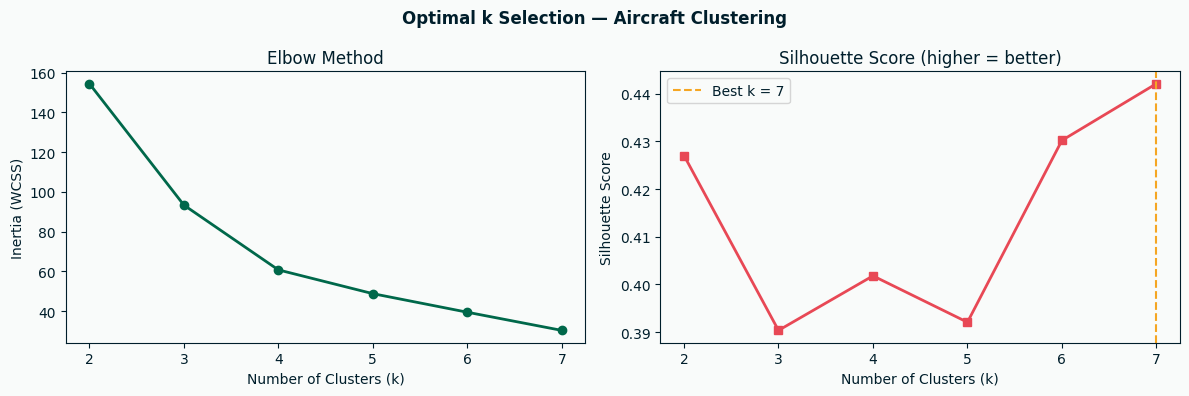

  Suggested k = 7  (silhouette = 0.442)

[Aircraft] PCA explained variance: [0.615 0.207]
[Aircraft] Silhouette score (k=7): 0.442


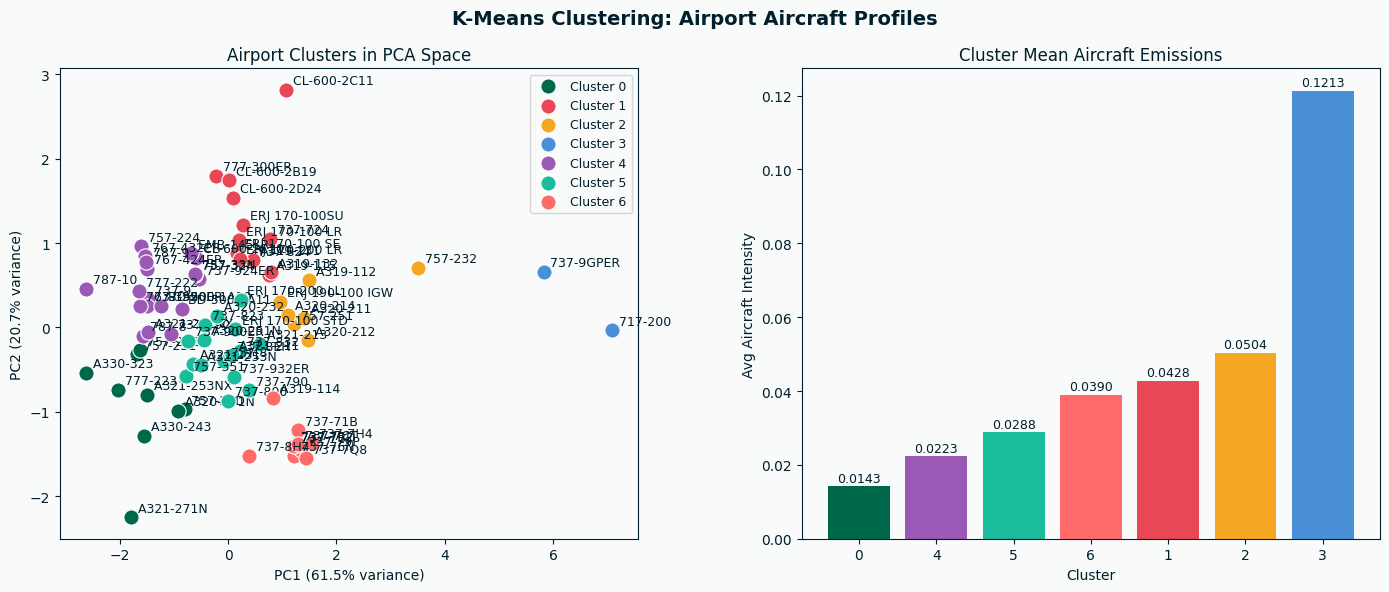

In [ ]:
aircraft_features = df.groupby("ACFT MODEL").agg(
    avg_CO2        = ("Total_CO2",    "mean"),
    avg_NOx        = ("Total_NOx",    "mean"),
    avg_CO2_per_km = ("CO2_per_km",   "median"),
    avg_NOx_per_km = ("NOx_per_km",   "median"),
    avg_distance   = ("DISTANCE",     "mean"),
    avg_taxi_out   = ("TAXI_OUT",     "mean"),
    flight_count   = ("Total_CO2",    "size"),
).query("flight_count >= 500").dropna()

ACFT_FEATURES = ["avg_CO2_per_km", "avg_NOx_per_km", "avg_distance", "avg_taxi_out"]

best_k = plot_elbow_silhouette(aircraft_features, ACFT_FEATURES, "Aircraft")
acft_result, acft_pca, acft_explained, _ = run_clustering(
    aircraft_features, ACFT_FEATURES, "Aircraft", n_clusters=best_k
)
plot_pca_clusters(acft_result, acft_explained, "Aircraft", "avg_CO2_per_km")

In [ ]:
for cluster in acft_result['Cluster'].unique():
    aircrafts = acft_result[acft_result['Cluster'] == cluster].index.tolist()
    subset = df[df['ACFT MODEL'].isin(aircrafts)]
    print(f"\nCluster {cluster}: {aircrafts}")
    print(f"  Avg CO2: {subset['Total_CO2'].mean():.2f} kg")
    print(f"  Avg CO2 per km: {subset['CO2_per_km'].mean():.4f} kg/km")
    print(f"  Avg NOx: {subset['Total_NOx'].mean():.2f} kg")
    print(f"  Avg distance: {subset['DISTANCE'].mean():.0f} miles")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")
    print(f"  Flight count: {len(subset)}")


Cluster 3: ['717-200             ', '737-9GPER           ']
  Avg CO2: 18.77 kg
  Avg CO2 per km: 0.1388 kg/km
  Avg NOx: 3.67 kg
  Avg distance: 171 miles
  Avg taxi out: 12.6 min
  Flight count: 24365

Cluster 6: ['737-71B             ', '737-752             ', '737-76N             ', '737-79P             ', '737-7BD             ', '737-7CT             ', '737-7H4             ', '737-7Q8             ', '737-8H4             ', 'A319-114            ']
  Avg CO2: 24.93 kg
  Avg CO2 per km: 0.0427 kg/km
  Avg NOx: 5.54 kg
  Avg distance: 734 miles
  Avg taxi out: 15.0 min
  Flight count: 73901

Cluster 1: ['737-724             ', '737-824             ', '777-300ER           ', 'A319-115            ', 'A319-131            ', 'A319-132            ', 'CL-600-2B19         ', 'CL-600-2C11         ', 'CL-600-2D24         ', 'ERJ 170-100 LR      ', 'ERJ 170-100 SE      ', 'ERJ 170-100SU       ', 'ERJ 170-200 LR      ']
  Avg CO2: 19.73 kg
  Avg CO2 per km: 0.0505 kg/km
  Avg NOx: 3.55 kg
  Avg

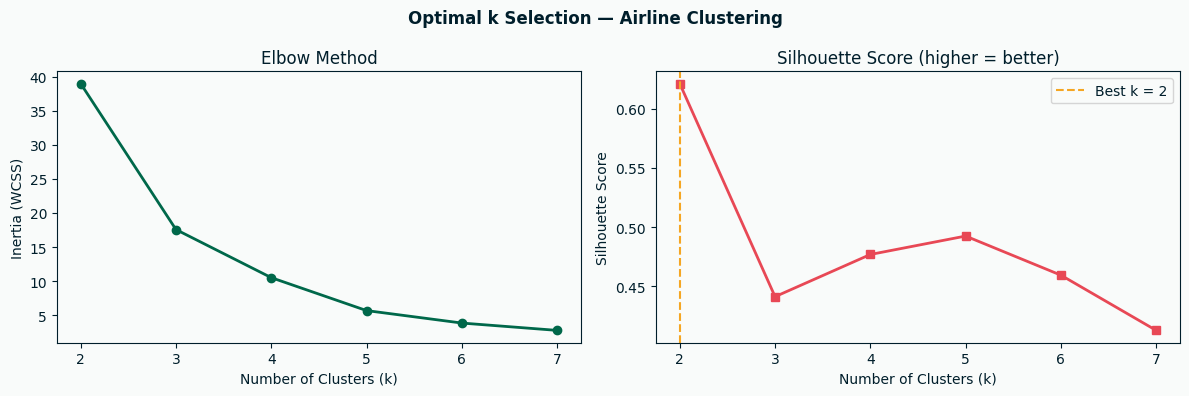

  Suggested k = 2  (silhouette = 0.621)

[Airline] PCA explained variance: [0.433 0.282]
[Airline] Silhouette score (k=2): 0.621


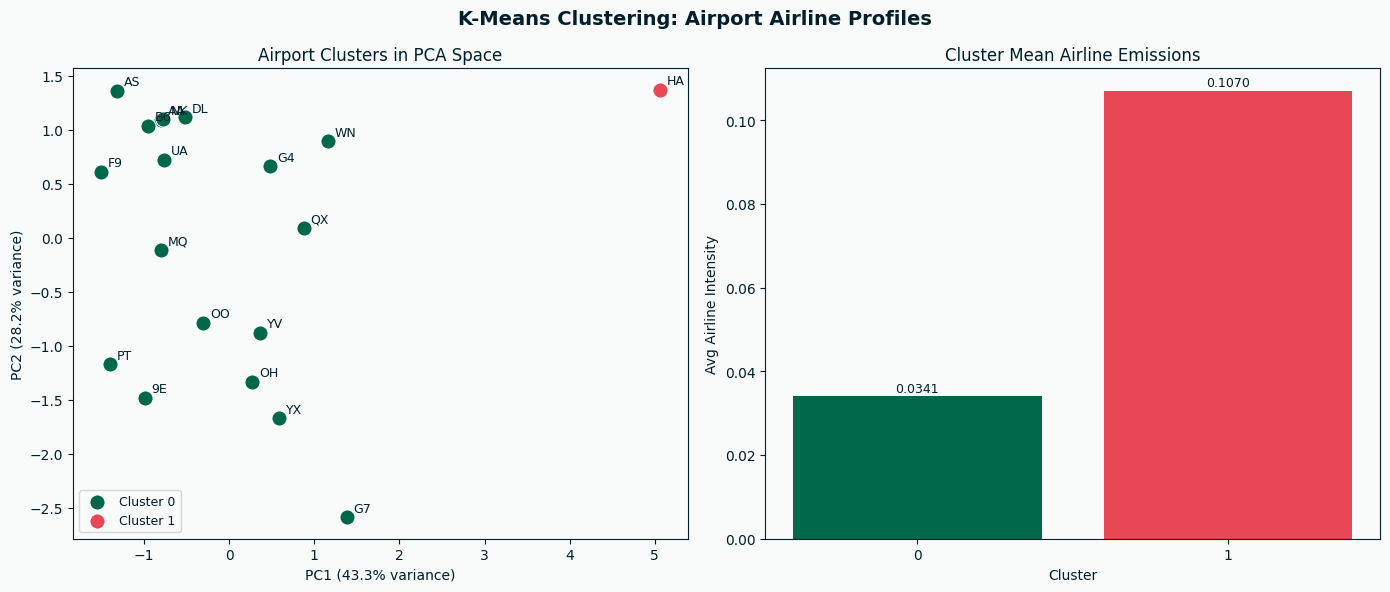


Cluster 0: ['9E', 'AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'G7', 'MQ', 'NK', 'OH', 'OO', 'PT', 'QX', 'UA', 'WN', 'YV', 'YX']
  Avg CO2: 26.10 kg
  Avg CO2 per km: 0.0367 kg/km
  Avg distance: 1112 miles
  Avg taxi out: 20.7 min
  Flight count: 1501155

Cluster 1: ['HA']
  Avg CO2: 26.12 kg
  Avg CO2 per km: 0.0981 kg/km
  Avg distance: 1205 miles
  Avg taxi out: 13.8 min
  Flight count: 31002


In [ ]:
airline_features = df.groupby("OP_CARRIER").agg(
    avg_CO2        = ("Total_CO2",    "mean"),
    avg_NOx        = ("Total_NOx",    "mean"),
    avg_CO2_per_km = ("CO2_per_km",   "median"),
    avg_NOx_per_km = ("NOx_per_km",   "median"),
    avg_distance   = ("DISTANCE",     "mean"),
    avg_taxi_out   = ("TAXI_OUT",     "mean"),
    avg_taxi_in    = ("TAXI_IN",      "mean"),
    flight_count   = ("Total_CO2",    "size"),
).query("flight_count >= 500").dropna()

AIRLINE_FEATURES = ["avg_CO2_per_km", "avg_NOx_per_km", "avg_distance", "avg_taxi_out", "avg_taxi_in"]

best_k = plot_elbow_silhouette(airline_features, AIRLINE_FEATURES, "Airline")
airline_result, airline_pca, airline_explained, _ = run_clustering(
    airline_features, AIRLINE_FEATURES, "Airline", n_clusters=best_k
)
plot_pca_clusters(airline_result, airline_explained, "Airline", "avg_CO2_per_km")

# 각 클러스터 특징
for cluster in airline_result['Cluster'].unique():
    airlines = airline_result[airline_result['Cluster'] == cluster].index.tolist()
    subset = df[df['OP_CARRIER'].isin(airlines)]
    print(f"\nCluster {cluster}: {airlines}")
    print(f"  Avg CO2: {subset['Total_CO2'].mean():.2f} kg")
    print(f"  Avg CO2 per km: {subset['CO2_per_km'].mean():.4f} kg/km")
    print(f"  Avg distance: {subset['DISTANCE'].mean():.0f} miles")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")
    print(f"  Flight count: {len(subset)}")

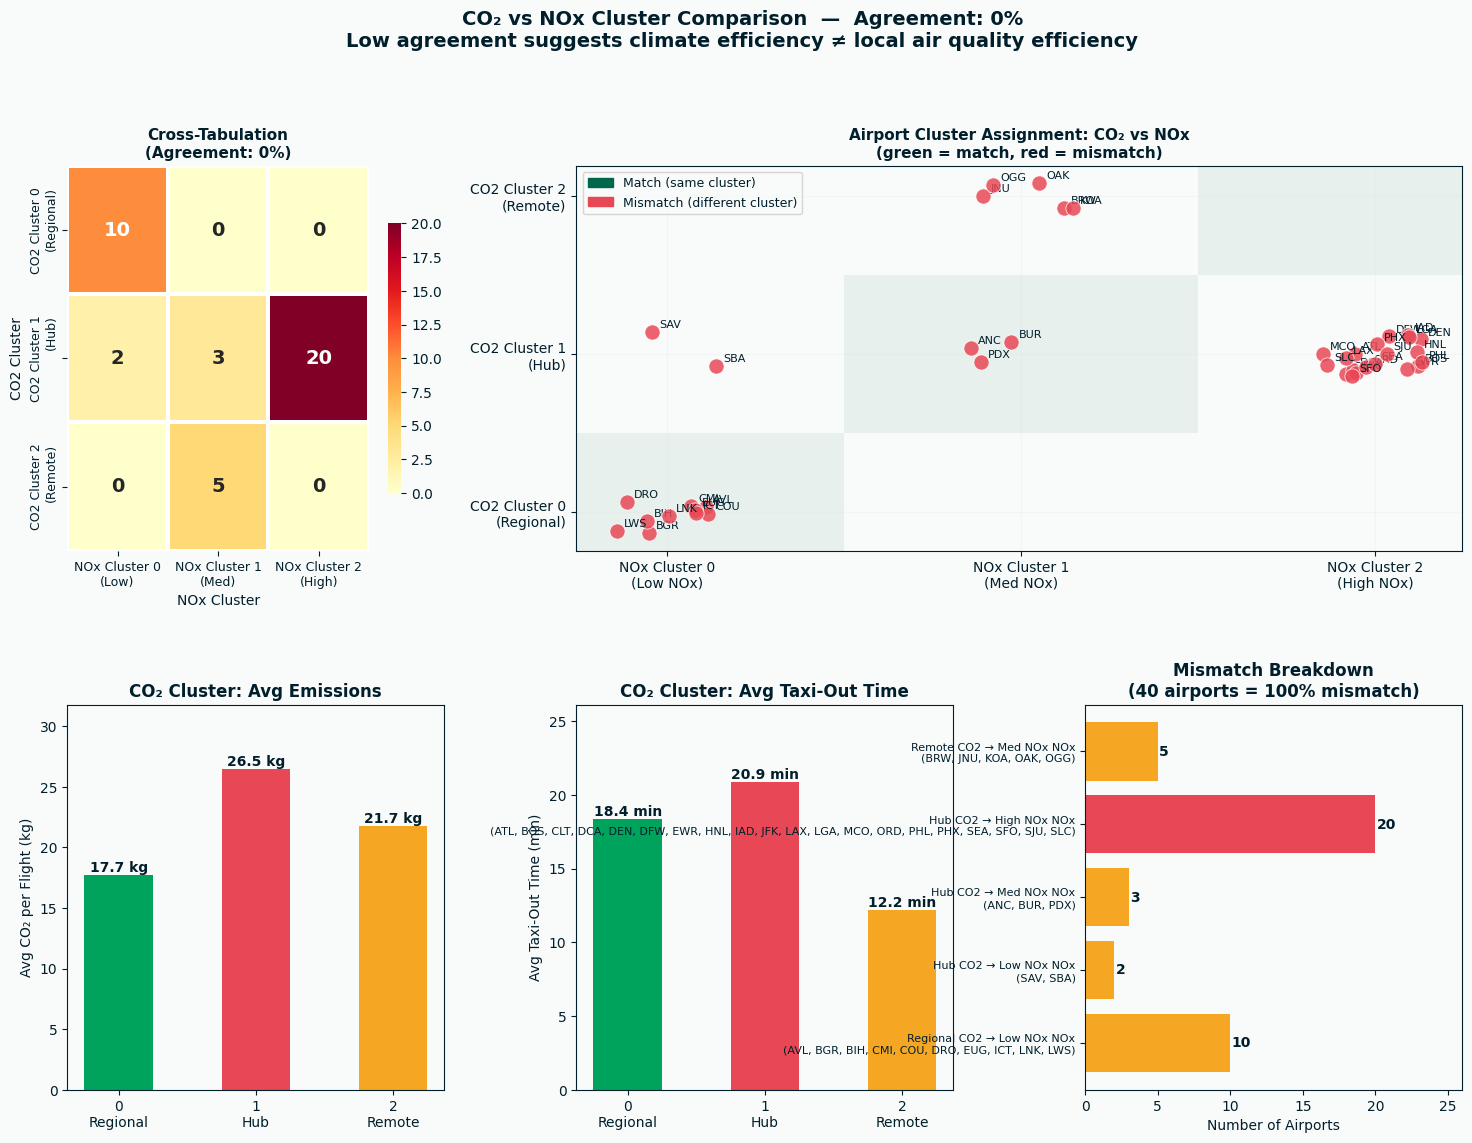

-> cluster_comparison_co2_nox.png


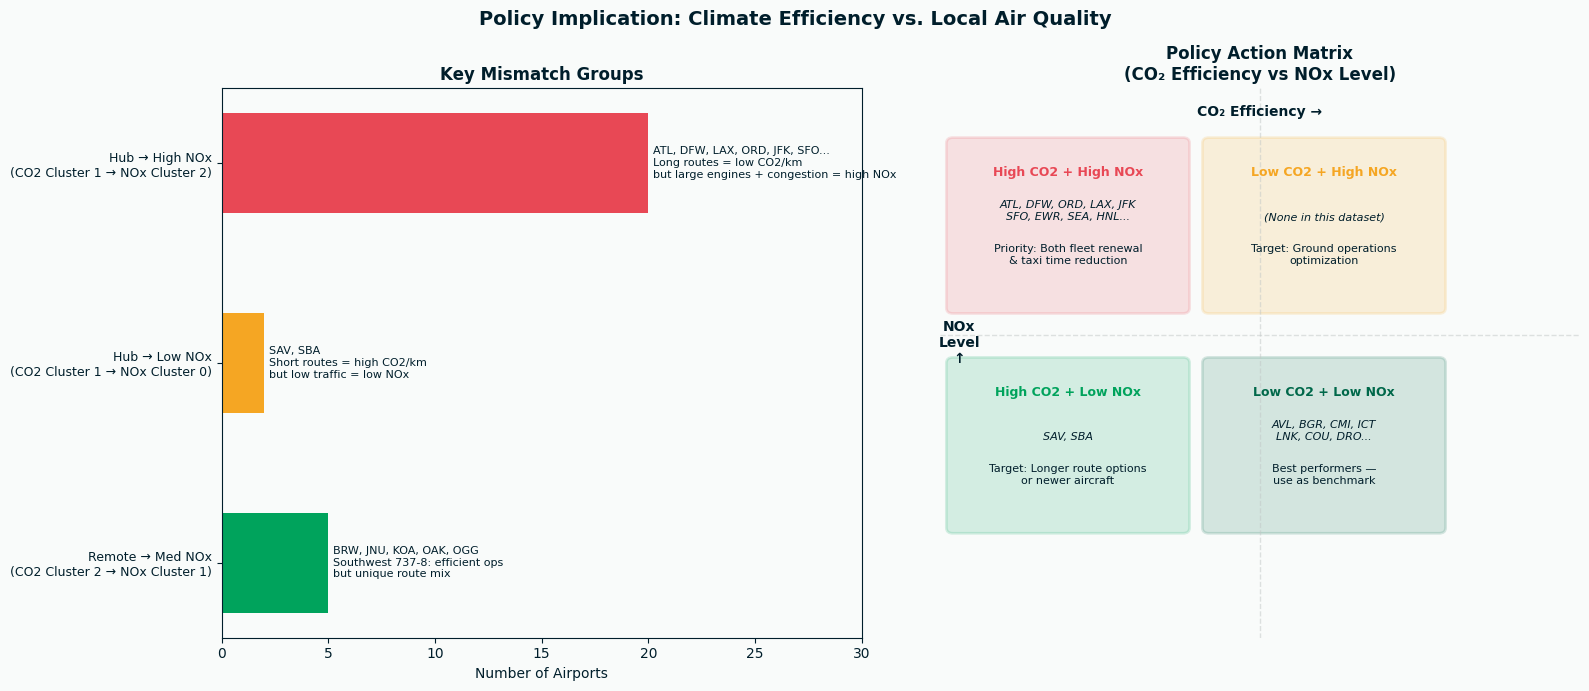

-> cluster_policy_matrix.png

Done! Output files:
  cluster_comparison_co2_nox.png
  cluster_policy_matrix.png


In [ ]:
"""
Cluster Analysis: CO2 vs NOx Cluster Comparison
CIVENG 160D Final Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─── Style ────────────────────────────────────────────────────────────────────
PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#C1C7C6",
    "bg":        "#F9FBFA",
}
OUTPUT_DIR = "./"

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.edgecolor":   PALETTE["secondary"], "text.color": PALETTE["secondary"],
    "font.family":      "DejaVu Sans",
})

# ─── Data: Cluster assignments from K-means ───────────────────────────────────
# CO2 Clusters
co2_clusters = {
    **{a: "0\nRegional" for a in ['AVL','BGR','BIH','CMI','COU','DRO','EUG','ICT','LNK','LWS']},
    **{a: "1\nHub"      for a in ['ANC','ATL','BOS','BUR','CLT','DCA','DEN','DFW','EWR',
                                   'HNL','IAD','JFK','LAX','LGA','MCO','ORD','PDX','PHL',
                                   'PHX','SAV','SBA','SEA','SFO','SJU','SLC']},
    **{a: "2\nRemote"   for a in ['BRW','JNU','KOA','OAK','OGG']},
}

# NOx Clusters
nox_clusters = {
    **{a: "0\nLow NOx"  for a in ['AVL','BGR','BIH','CMI','COU','DRO','EUG','ICT',
                                   'LNK','LWS','SAV','SBA']},
    **{a: "1\nMed NOx"  for a in ['ANC','BRW','BUR','JNU','KOA','OAK','OGG','PDX']},
    **{a: "2\nHigh NOx" for a in ['ATL','BOS','CLT','DCA','DEN','DFW','EWR','HNL',
                                   'IAD','JFK','LAX','LGA','MCO','ORD','PHL','PHX',
                                   'SEA','SFO','SJU','SLC']},
}

# Cluster profiles
co2_profile = {
    "0\nRegional": {"avg_co2": 17.72, "taxi": 18.4, "airline": "SkyWest", "acft": "ERJ 170-200"},
    "1\nHub":      {"avg_co2": 26.48, "taxi": 20.9, "airline": "American", "acft": "A321-231"},
    "2\nRemote":   {"avg_co2": 21.74, "taxi": 12.2, "airline": "Southwest", "acft": "737-8"},
}

comparison = pd.DataFrame({
    "Airport":      list(co2_clusters.keys()),
    "CO2_Cluster":  list(co2_clusters.values()),
    "NOx_Cluster":  [nox_clusters[a] for a in co2_clusters.keys()],
})
comparison["Match"] = comparison["CO2_Cluster"] == comparison["NOx_Cluster"]
agreement = comparison["Match"].mean()

# Colors
CO2_COLORS = {
    "0\nRegional": PALETTE["accent"],
    "1\nHub":      PALETTE["danger"],
    "2\nRemote":   PALETTE["warning"],
}
NOX_COLORS = {
    "0\nLow NOx":  PALETTE["accent"],
    "1\nMed NOx":  PALETTE["warning"],
    "2\nHigh NOx": PALETTE["danger"],
}


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 1: Cross-tabulation Heatmap + Profile Bars
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f"CO₂ vs NOx Cluster Comparison  —  Agreement: {agreement*100:.0f}%\n"
    f"Low agreement suggests climate efficiency ≠ local air quality efficiency",
    fontsize=14, fontweight="bold", color=PALETTE["secondary"], y=1.01
)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# ── 1-1. Cross-tab Heatmap ──
ax1 = fig.add_subplot(gs[0, 0])
crosstab = pd.crosstab(
    comparison["CO2_Cluster"],
    comparison["NOx_Cluster"]
)
sns.heatmap(
    crosstab, ax=ax1,
    annot=True, fmt="d", annot_kws={"size": 14, "weight": "bold"},
    cmap="YlOrRd", linewidths=1.5,
    cbar_kws={"shrink": 0.7},
    xticklabels=["NOx Cluster 0\n(Low)", "NOx Cluster 1\n(Med)", "NOx Cluster 2\n(High)"],
    yticklabels=["CO2 Cluster 0\n(Regional)", "CO2 Cluster 1\n(Hub)", "CO2 Cluster 2\n(Remote)"],
)
ax1.set_title(f"Cross-Tabulation\n(Agreement: {agreement*100:.0f}%)",
              fontweight="bold", fontsize=11)
ax1.set_xlabel("NOx Cluster", fontsize=10)
ax1.set_ylabel("CO2 Cluster", fontsize=10)
ax1.tick_params(labelsize=9)

# ── 1-2. Airport-level Scatter: CO2 vs NOx cluster ──
ax2 = fig.add_subplot(gs[0, 1:])
match_color = {True: PALETTE["primary"], False: PALETTE["danger"]}

# jitter for readability
np.random.seed(42)
co2_order = {"0\nRegional": 0, "1\nHub": 1, "2\nRemote": 2}
nox_order  = {"0\nLow NOx": 0, "1\nMed NOx": 1, "2\nHigh NOx": 2}

x = comparison["NOx_Cluster"].map(nox_order) + np.random.uniform(-0.15, 0.15, len(comparison))
y = comparison["CO2_Cluster"].map(co2_order) + np.random.uniform(-0.15, 0.15, len(comparison))

for _, row in comparison.iterrows():
    xi = nox_order[row["NOx_Cluster"]] + np.random.uniform(-0.15, 0.15)
    yi = co2_order[row["CO2_Cluster"]] + np.random.uniform(-0.15, 0.15)
    color = PALETTE["primary"] if row["Match"] else PALETTE["danger"]
    ax2.scatter(xi, yi, s=120, color=color, alpha=0.85,
                edgecolors="white", linewidths=0.6, zorder=3)
    ax2.annotate(row["Airport"], (xi, yi),
                 textcoords="offset points", xytext=(5, 3), fontsize=8,
                 color=PALETTE["secondary"])

ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(["NOx Cluster 0\n(Low NOx)", "NOx Cluster 1\n(Med NOx)", "NOx Cluster 2\n(High NOx)"])
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(["CO2 Cluster 0\n(Regional)", "CO2 Cluster 1\n(Hub)", "CO2 Cluster 2\n(Remote)"])
ax2.set_title("Airport Cluster Assignment: CO₂ vs NOx\n(green = match, red = mismatch)",
              fontweight="bold", fontsize=11)

# diagonal = perfect agreement line
for i in range(3):
    ax2.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                                 fill=True, facecolor=PALETTE["primary"],
                                 alpha=0.07, zorder=1))

legend_patches = [
    mpatches.Patch(color=PALETTE["primary"], label="Match (same cluster)"),
    mpatches.Patch(color=PALETTE["danger"],  label="Mismatch (different cluster)"),
]
ax2.legend(handles=legend_patches, fontsize=9, loc="upper left")
ax2.grid(True, alpha=0.3)


# ── 2-1. CO2 Cluster Profiles ──
ax3 = fig.add_subplot(gs[1, 0])
clusters_co2 = list(co2_profile.keys())
co2_vals     = [co2_profile[c]["avg_co2"] for c in clusters_co2]
colors_co2   = [CO2_COLORS[c] for c in clusters_co2]
bars = ax3.bar(clusters_co2, co2_vals, color=colors_co2, edgecolor="none", width=0.5)
for bar, val in zip(bars, co2_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f} kg", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylabel("Avg CO₂ per Flight (kg)")
ax3.set_title("CO₂ Cluster: Avg Emissions", fontweight="bold")
ax3.set_ylim(0, max(co2_vals) * 1.2)

# ── 2-2. Taxi Time by CO2 Cluster ──
ax4 = fig.add_subplot(gs[1, 1])
taxi_vals = [co2_profile[c]["taxi"] for c in clusters_co2]
bars = ax4.bar(clusters_co2, taxi_vals, color=colors_co2, edgecolor="none", width=0.5)
for bar, val in zip(bars, taxi_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{val:.1f} min", ha="center", fontsize=10, fontweight="bold")
ax4.set_ylabel("Avg Taxi-Out Time (min)")
ax4.set_title("CO₂ Cluster: Avg Taxi-Out Time", fontweight="bold")
ax4.set_ylim(0, max(taxi_vals) * 1.25)

# ── 2-3. Key Mismatches ──
ax5 = fig.add_subplot(gs[1, 2])
mismatch = comparison[~comparison["Match"]].copy()
mismatch["label"] = mismatch["Airport"] + "\n" + \
                    mismatch["CO2_Cluster"].str.split("\n").str[1] + \
                    "→" + mismatch["NOx_Cluster"].str.split("\n").str[1]

mismatch_groups = mismatch.groupby(
    ["CO2_Cluster", "NOx_Cluster"]
).agg(airports=("Airport", lambda x: ", ".join(sorted(x))),
      count=("Airport", "count")).reset_index()

y_pos = range(len(mismatch_groups))
colors_bar = [PALETTE["danger"] if "High" in r["NOx_Cluster"]
              else PALETTE["warning"] for _, r in mismatch_groups.iterrows()]
bars = ax5.barh(y_pos, mismatch_groups["count"], color=colors_bar, edgecolor="none")

labels = [f"{r['CO2_Cluster'].split(chr(10))[1]} CO2 → {r['NOx_Cluster'].split(chr(10))[1]} NOx\n({r['airports']})"
          for _, r in mismatch_groups.iterrows()]
ax5.set_yticks(y_pos)
ax5.set_yticklabels(labels, fontsize=8)
ax5.set_xlabel("Number of Airports")
ax5.set_title(f"Mismatch Breakdown\n({len(mismatch)} airports = {(1-agreement)*100:.0f}% mismatch)",
              fontweight="bold")
for bar, val in zip(bars, mismatch_groups["count"]):
    ax5.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=10, fontweight="bold")
ax5.set_xlim(0, mismatch_groups["count"].max() * 1.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_comparison_co2_nox.png", dpi=150, bbox_inches="tight")
plt.show()
print("-> cluster_comparison_co2_nox.png")


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2: Policy Implication Summary
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle("Policy Implication: Climate Efficiency vs. Local Air Quality",
              fontsize=14, fontweight="bold", color=PALETTE["secondary"])

# ── Left: Key mismatching airports spotlight ──
ax = axes[0]
spotlight = {
    "Hub → High NOx\n(CO2 Cluster 1 → NOx Cluster 2)": {
        "airports": ["ATL","DFW","LAX","ORD","JFK","SFO","EWR","BOS",
                     "DEN","SEA","HNL","LGA","PHL","MCO","PHX","DCA","IAD","CLT","SJU","SLC"],
        "msg": "Long routes = low CO2/km\nbut large engines + congestion = high NOx",
        "color": PALETTE["danger"],
    },
    "Hub → Low NOx\n(CO2 Cluster 1 → NOx Cluster 0)": {
        "airports": ["SAV", "SBA"],
        "msg": "Short routes = high CO2/km\nbut low traffic = low NOx",
        "color": PALETTE["warning"],
    },
    "Remote → Med NOx\n(CO2 Cluster 2 → NOx Cluster 1)": {
        "airports": ["BRW", "JNU", "KOA", "OAK", "OGG"],
        "msg": "Southwest 737-8: efficient ops\nbut unique route mix",
        "color": PALETTE["accent"],
    },
}

y = 0
for label, info in spotlight.items():
    ax.barh(y, len(info["airports"]), color=info["color"], edgecolor="none", height=0.5)
    ax.text(len(info["airports"]) + 0.2, y,
            f"{', '.join(info['airports'][:6])}{'...' if len(info['airports'])>6 else ''}\n{info['msg']}",
            va="center", fontsize=8, color=PALETTE["secondary"])
    y -= 1

ax.set_yticks([0, -1, -2])
ax.set_yticklabels(list(spotlight.keys()), fontsize=9)
ax.set_xlabel("Number of Airports")
ax.set_title("Key Mismatch Groups", fontweight="bold")
ax.set_xlim(0, 30)
ax.axvline(0, color=PALETTE["secondary"], linewidth=0.5)

# ── Right: Policy matrix ──
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis("off")

policy_data = [
    (2, 7.5, PALETTE["danger"],  "High CO2 + High NOx",
     "ATL, DFW, ORD, LAX, JFK\nSFO, EWR, SEA, HNL...",
     "Priority: Both fleet renewal\n& taxi time reduction"),
    (6, 7.5, PALETTE["warning"], "Low CO2 + High NOx",
     "(None in this dataset)",
     "Target: Ground operations\noptimization"),
    (2, 3.5, PALETTE["accent"],  "High CO2 + Low NOx",
     "SAV, SBA",
     "Target: Longer route options\nor newer aircraft"),
    (6, 3.5, PALETTE["primary"], "Low CO2 + Low NOx",
     "AVL, BGR, CMI, ICT\nLNK, COU, DRO...",
     "Best performers —\nuse as benchmark"),
]

for x, y, color, title, airports, action in policy_data:
    rect = mpatches.FancyBboxPatch((x-1.8, y-1.5), 3.6, 3.0,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, alpha=0.15,
                                    edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y+0.9, title, ha="center", fontsize=9,
            fontweight="bold", color=color)
    ax.text(x, y+0.1, airports, ha="center", fontsize=8,
            color=PALETTE["secondary"], style="italic")
    ax.text(x, y-0.7, action, ha="center", fontsize=8,
            color=PALETTE["secondary"])

ax.text(5, 9.5, "CO₂ Efficiency →", ha="center", fontsize=10,
        fontweight="bold", color=PALETTE["secondary"])
ax.text(0.3, 5, "NOx\nLevel\n↑", ha="center", fontsize=10,
        fontweight="bold", color=PALETTE["secondary"])
ax.axhline(5.5, color=PALETTE["muted"], linewidth=1, linestyle="--", alpha=0.5)
ax.axvline(5,   color=PALETTE["muted"], linewidth=1, linestyle="--", alpha=0.5)
ax.set_title("Policy Action Matrix\n(CO₂ Efficiency vs NOx Level)",
             fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_policy_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("-> cluster_policy_matrix.png")

print("\nDone! Output files:")
print("  cluster_comparison_co2_nox.png")
print("  cluster_policy_matrix.png")

In [ ]:
for cluster in nox_result['Cluster'].unique():
    airports = nox_result[nox_result['Cluster'] == cluster].index.tolist()
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\nCluster {cluster}: {airports}")
    print(f"  Avg NOx: {subset['Total_NOx'].mean():.2f} kg")
    print(f"  Avg NOx per km: {subset['NOx_per_km'].mean():.4f} kg/km")
    print(f"  Avg distance: {subset['DISTANCE'].mean():.0f} miles")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")
    print(f"  Boeing share: {(subset['ACFT MFR CLEAN']=='BOEING').mean()*100:.1f}%")
    print(f"  Airbus share: {(subset['ACFT MFR CLEAN']=='AIRBUS').mean()*100:.1f}%")
    print("  Top 3 airlines:")
    print(subset['OP_CARRIER'].value_counts(normalize=True).head(3).mul(100).round(1).to_string())
    print("  Top 5 aircraft:")
    print(subset['ACFT MODEL'].value_counts(normalize=True).head(5).mul(100).round(1).to_string())
    route_dist = subset['ROUTE_TYPE'].value_counts(normalize=True) * 100
    print("  Route mix:")
    print(route_dist.round(1).to_string())


Cluster 1: ['ANC', 'BRW', 'BUR', 'JNU', 'KOA', 'OAK', 'OGG', 'PDX']
  Avg NOx: 5.65 kg
  Avg NOx per km: 0.0125 kg/km
  Avg distance: 1069 miles
  Avg taxi out: 15.1 min
  Boeing share: 70.9%
  Airbus share: 15.3%
  Top 3 airlines:
OP_CARRIER
WN    25.0
AS    24.8
HA    10.6
  Top 5 aircraft:
ACFT MODEL
737-8                   15.3
ERJ 170-200 LR          10.6
737-7H4                  8.6
737-9                    8.3
717-200                  8.0
  Route mix:
ROUTE_TYPE
Regional           29.6
Long Haul          25.9
Medium Haul        24.0
Short Hopper       18.8
Ultra Long Haul     1.7

Cluster 2: ['ATL', 'BOS', 'CLT', 'DCA', 'DEN', 'DFW', 'EWR', 'HNL', 'IAD', 'JFK', 'LAX', 'LGA', 'MCO', 'ORD', 'PHL', 'PHX', 'SEA', 'SFO', 'SJU', 'SLC']
  Avg NOx: 6.15 kg
  Avg NOx per km: 0.0078 kg/km
  Avg distance: 1145 miles
  Avg taxi out: 21.2 min
  Boeing share: 43.3%
  Airbus share: 42.3%
  Top 3 airlines:
OP_CARRIER
AA    22.3
UA    19.5
DL    17.6
  Top 5 aircraft:
ACFT MODEL
A321-231       

In [ ]:
sju = df[df['ORIGIN'] == 'OAK']
print(f"Avg NOx: {sju['Total_NOx'].mean():.2f} kg")
print(f"Avg NOx per km: {sju['NOx_per_km'].mean():.4f}")
print(f"Avg distance: {sju['DISTANCE'].mean():.0f} miles")
print(f"Boeing share: {(sju['ACFT MFR CLEAN']=='BOEING').mean()*100:.1f}%")
print(f"Airbus share: {(sju['ACFT MFR CLEAN']=='AIRBUS').mean()*100:.1f}%")
print(sju['OP_CARRIER'].value_counts().head(3))

Avg NOx: 5.38 kg
Avg NOx per km: 0.0103
Avg distance: 710 miles
Boeing share: 81.3%
Airbus share: 5.0%
OP_CARRIER
WN    13270
QX     1303
OO     1014
Name: count, dtype: int64


In [ ]:
for cluster, airports in [
    ("Cluster 1", ['ANC', 'BRW', 'BUR', 'JNU', 'KOA', 'OAK', 'OGG', 'PDX']),
    ("Cluster 2", ['ATL', 'BOS', 'CLT', 'DCA', 'DEN', 'DFW', 'EWR', 'HNL', 'IAD', 'JFK', 'LAX', 'LGA', 'MCO', 'ORD', 'PHL', 'PHX', 'SEA', 'SFO', 'SJU', 'SLC'])
]:
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\n{cluster}:")
    print(subset[['NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)']].mean().round(3))


Cluster 1:
NOx EI T/O (g/kg)     33.941
NOx EI C/O (g/kg)     21.941
NOx EI App (g/kg)     10.370
NOx EI Idle (g/kg)     4.661
dtype: float64

Cluster 2:
NOx EI T/O (g/kg)     31.294
NOx EI C/O (g/kg)     21.740
NOx EI App (g/kg)     10.095
NOx EI Idle (g/kg)     4.726
dtype: float64


In [ ]:
for cluster, airports in [
    ("Cluster 1", ['ANC', 'BRW', 'BUR', 'JNU', 'KOA', 'OAK', 'OGG', 'PDX']),
    ("Cluster 2", ['ATL', 'BOS', 'CLT', 'DCA', 'DEN', 'DFW', 'EWR', 'HNL', 'IAD', 'JFK', 'LAX', 'LGA', 'MCO', 'ORD', 'PHL', 'PHX', 'SEA', 'SFO', 'SJU', 'SLC'])
]:
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\n{cluster}:")
    print(subset[['Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)']].mean().round(4))


Cluster 1:
Fuel Flow T/O (kg/sec)     1.0878
Fuel Flow C/O (kg/sec)     0.8854
Fuel Flow App (kg/sec)     0.2964
Fuel Flow Idle (kg/sec)    0.1025
dtype: float64

Cluster 2:
Fuel Flow T/O (kg/sec)     1.1566
Fuel Flow C/O (kg/sec)     0.9409
Fuel Flow App (kg/sec)     0.3166
Fuel Flow Idle (kg/sec)    0.1086
dtype: float64


In [ ]:
for cluster, airports in [
    ("Cluster 1", ['ANC', 'BRW', 'BUR', 'JNU', 'KOA', 'OAK', 'OGG', 'PDX']),
    ("Cluster 2", ['ATL', 'BOS', 'CLT', 'DCA', 'DEN', 'DFW', 'EWR', 'HNL', 'IAD', 'JFK', 'LAX', 'LGA', 'MCO', 'ORD', 'PHL', 'PHX', 'SEA', 'SFO', 'SJU', 'SLC'])
]:
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"{cluster}: {len(subset):,} flights, avg distance: {subset['DISTANCE'].mean():.0f} miles, avg NOx/km: {subset['NOx_per_km'].mean():.4f}")

Cluster 1: 121,243 flights, avg distance: 1069 miles, avg NOx/km: 0.0125
Cluster 2: 1,348,864 flights, avg distance: 1145 miles, avg NOx/km: 0.0078


In [ ]:
special = df[df['ORIGIN'].isin(['BRW', 'OAK'])]
print(f"Avg NOx/km: {special['NOx_per_km'].mean():.4f}")
print(f"Avg distance: {special['DISTANCE'].mean():.0f} miles")
print(f"Flight count: {len(special)}")

Avg NOx/km: 0.0102
Avg distance: 710 miles
Flight count: 17392


In [ ]:
hawaii_all = df[df['ORIGIN'].isin(['KOA', 'OGG'])]
print(hawaii_all['ACFT MODEL'].value_counts(normalize=True).head(5).mul(100).round(1))
print(f"\nAvg distance: {hawaii_all['DISTANCE'].mean():.0f} miles")
print(hawaii_all['ROUTE_TYPE'].value_counts(normalize=True).mul(100).round(1))

ACFT MODEL
717-200                 34.2
737-8                   31.1
A321-253NX               5.5
737-9                    5.2
737-890                  5.1
Name: proportion, dtype: float64

Avg distance: 1282 miles
ROUTE_TYPE
Short Hopper       54.3
Long Haul          41.1
Ultra Long Haul     4.6
Name: proportion, dtype: float64


In [ ]:
hawaii_co2 = df[df['ORIGIN'].isin(['OGG'])]
print(f"Avg CO2: {hawaii_co2['Total_CO2'].mean():.2f} kg")
print(f"Avg CO2/km: {hawaii_co2['CO2_per_km'].mean():.4f}")
print(f"Avg distance: {hawaii_co2['DISTANCE'].mean():.0f} miles")

Avg CO2: 22.64 kg
Avg CO2/km: 0.1027
Avg distance: 1321 miles


In [ ]:
hnl = df[df['ORIGIN'] == 'OGG']
print(f"Avg CO2/km: {hnl['CO2_per_km'].mean():.4f}")
print(f"Avg distance: {hnl['DISTANCE'].mean():.0f} miles")
print(f"Boeing share: {(hnl['ACFT MFR CLEAN']=='BOEING').mean()*100:.1f}%")
print(f"Airbus share: {(hnl['ACFT MFR CLEAN']=='AIRBUS').mean()*100:.1f}%")
print(hnl['ROUTE_TYPE'].value_counts(normalize=True).mul(100).round(1))
print(hnl['OP_CARRIER'].value_counts().head(3))
print(hnl['ACFT MODEL'].value_counts().head(5).round(1))

Avg CO2/km: 0.1027
Avg distance: 1321 miles
Boeing share: 84.2%
Airbus share: 15.8%
ROUTE_TYPE
Short Hopper       52.5
Long Haul          42.0
Ultra Long Haul     5.5
Name: proportion, dtype: float64
OP_CARRIER
HA    6907
WN    4180
UA    2052
Name: count, dtype: int64
ACFT MODEL
737-8                   5719
717-200                 5489
737-9                    990
A321-271N                861
A321-253NX               830
Name: count, dtype: int64


In [ ]:
print(co2_result.loc['HNL', 'Cluster'])
print(nox_result.loc['HNL', 'Cluster'])

1
2


In [ ]:
for cluster, airports in [
    ("Cluster 0", ['AVL', 'BGR', 'BIH', 'CMI', 'COU', 'DRO', 'EUG', 'ICT', 'LNK', 'LWS']),
    ("Cluster 1", ['ATL', 'BOS', 'CLT', 'DCA', 'DEN', 'DFW', 'EWR', 'HNL', 'IAD', 'JFK', 'LAX', 'LGA', 'MCO', 'ORD', 'PHL', 'PHX', 'SEA', 'SFO', 'SJU', 'SLC']),
    ("Cluster 2", ['BRW', 'JNU', 'KOA', 'OAK', 'OGG'])
]:
    subset = df[df['ORIGIN'].isin(airports)]
    print(f"\n{cluster}:")
    print(f"  Avg taxi out: {subset['TAXI_OUT'].mean():.1f} min")
    print(f"  Median taxi out: {subset['TAXI_OUT'].median():.1f} min")
    print(f"  90th percentile: {subset['TAXI_OUT'].quantile(0.9):.1f} min")
    print(f"  Max taxi out: {subset['TAXI_OUT'].max():.1f} min")


Cluster 0:
  Avg taxi out: 18.4 min
  Median taxi out: 15.0 min
  90th percentile: 31.0 min
  Max taxi out: 180.0 min

Cluster 1:
  Avg taxi out: 21.2 min
  Median taxi out: 18.0 min
  90th percentile: 33.0 min
  Max taxi out: 890.0 min

Cluster 2:
  Avg taxi out: 12.2 min
  Median taxi out: 11.0 min
  90th percentile: 18.0 min
  Max taxi out: 133.0 min
